In [252]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [253]:
DATA_PATH=Path("data/star_classification.csv")
df=pd.read_csv(DATA_PATH)
df

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,GALAXY,0.000000,9374,57749,438
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,GALAXY,0.404895,7626,56934,866
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,GALAXY,0.143366,2764,54535,74
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,GALAXY,0.455040,6751,56368,470


In [254]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [255]:
df.isnull().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

In [256]:
df[df.duplicated()]

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID


In [257]:
df[df.duplicated('spec_obj_ID')]

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID


In [258]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
obj_ID,100000.0,1.237665e+18,8.438560e+12,1.237646e+18,1.237659e+18,1.237663e+18,1.237668e+18,1.237681e+18
alpha,100000.0,1.776291e+02,9.650224e+01,5.527828e-03,1.275182e+02,1.809007e+02,2.338950e+02,3.599998e+02
delta,100000.0,2.413530e+01,1.964467e+01,-1.878533e+01,5.146771e+00,2.364592e+01,3.990155e+01,8.300052e+01
u,100000.0,2.198047e+01,3.176929e+01,-9.999000e+03,2.035235e+01,2.217914e+01,2.368744e+01,3.278139e+01
g,100000.0,2.053139e+01,3.175029e+01,-9.999000e+03,1.896523e+01,2.109983e+01,2.212377e+01,3.160224e+01
r,100000.0,1.964576e+01,1.854760e+00,9.822070e+00,1.813583e+01,2.012529e+01,2.104478e+01,2.957186e+01
i,100000.0,1.908485e+01,1.757895e+00,9.469903e+00,1.773228e+01,1.940514e+01,2.039650e+01,3.214147e+01
z,100000.0,1.866881e+01,3.172815e+01,-9.999000e+03,1.746068e+01,1.900460e+01,1.992112e+01,2.938374e+01
run_ID,100000.0,4.481366e+03,1.964765e+03,1.090000e+02,3.187000e+03,4.188000e+03,5.326000e+03,8.162000e+03
rerun_ID,100000.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


In [259]:
id_cols = ['obj_ID','run_ID','rerun_ID','cam_col','field_ID','spec_obj_ID','plate','MJD','fiber_ID']

In [260]:
df[id_cols].nunique()

obj_ID          78053
run_ID            430
rerun_ID            1
cam_col             6
field_ID          856
spec_obj_ID    100000
plate            6284
MJD              2180
fiber_ID         1000
dtype: int64

#### rerun_ID constant, spec_obj_ID is unique

In [261]:
(df[['u','g','z','r','i']] == -9999).sum() 

u    1
g    1
z    1
r    0
i    0
dtype: int64

#### 1 row -> drop

In [262]:
df = df[df['u'] != -9999].reset_index(drop=True) 

In [263]:
df["class"].value_counts()

class
GALAXY    59445
STAR      21593
QSO       18961
Name: count, dtype: int64

<Axes: xlabel='class', ylabel='count'>

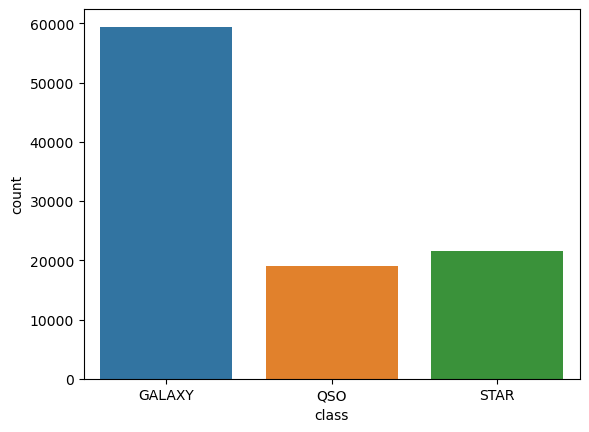

In [264]:
sns.countplot(data=df,x="class",hue="class")

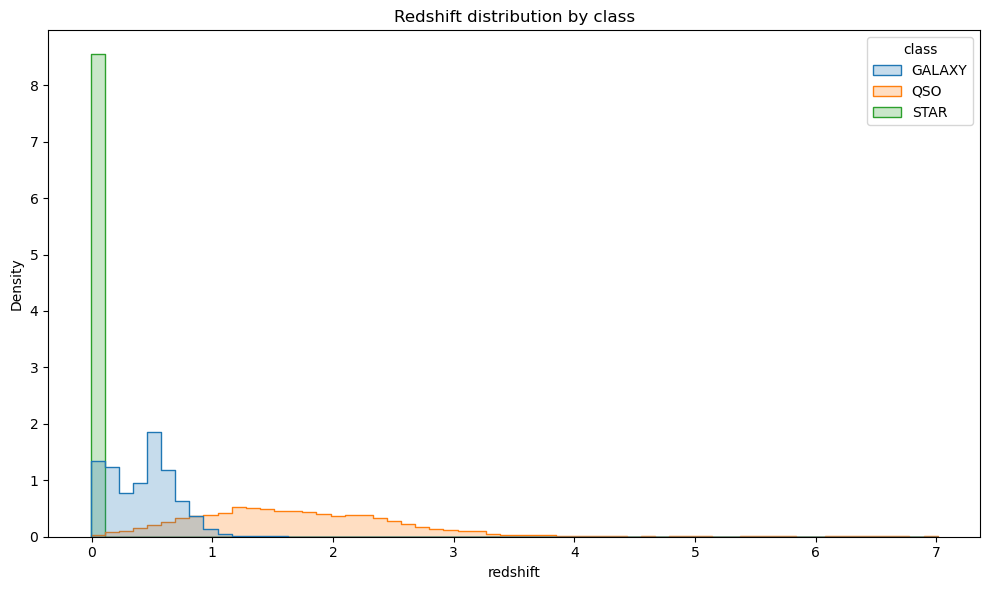

In [265]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='redshift',hue='class',bins=60,element='step',stat="density", common_norm=False)
plt.title('Redshift distribution by class')
plt.tight_layout()
plt.show()

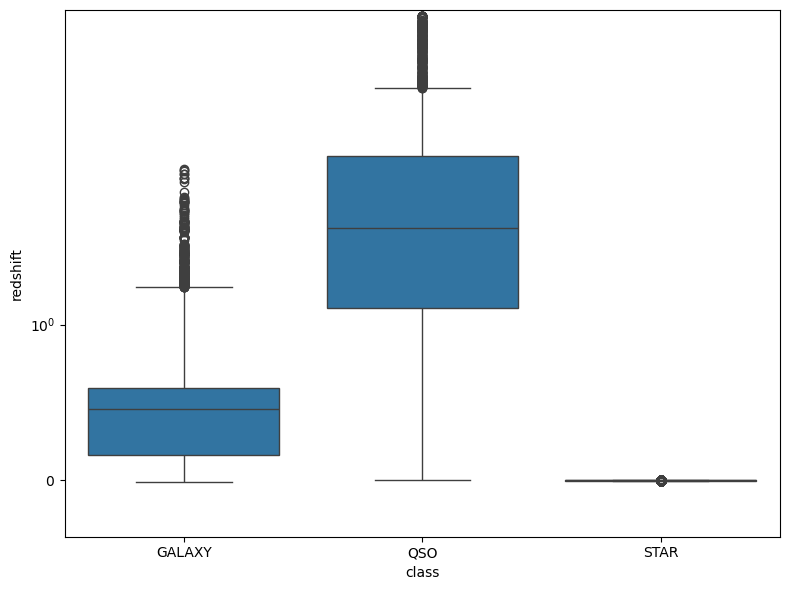

In [266]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='class', y='redshift'); plt.yscale('symlog')
plt.tight_layout()
plt.show()

#### Star  z ≈ 0
#### Galaxy z > 0
#### QSQ z >> 0

In [267]:
class_by_redshift=df.groupby('class')['redshift'].agg(['max','min','mean','median','std'])
class_by_redshift

,max,min,mean,median,std
class,,,,,
GALAXY,1.995524,-0.009971,0.421596,0.456274,0.264858
QSO,7.011245,0.000461,1.719676,1.617232,0.913954
STAR,0.004153,-0.004136,-0.000115,-0.000076,0.000465


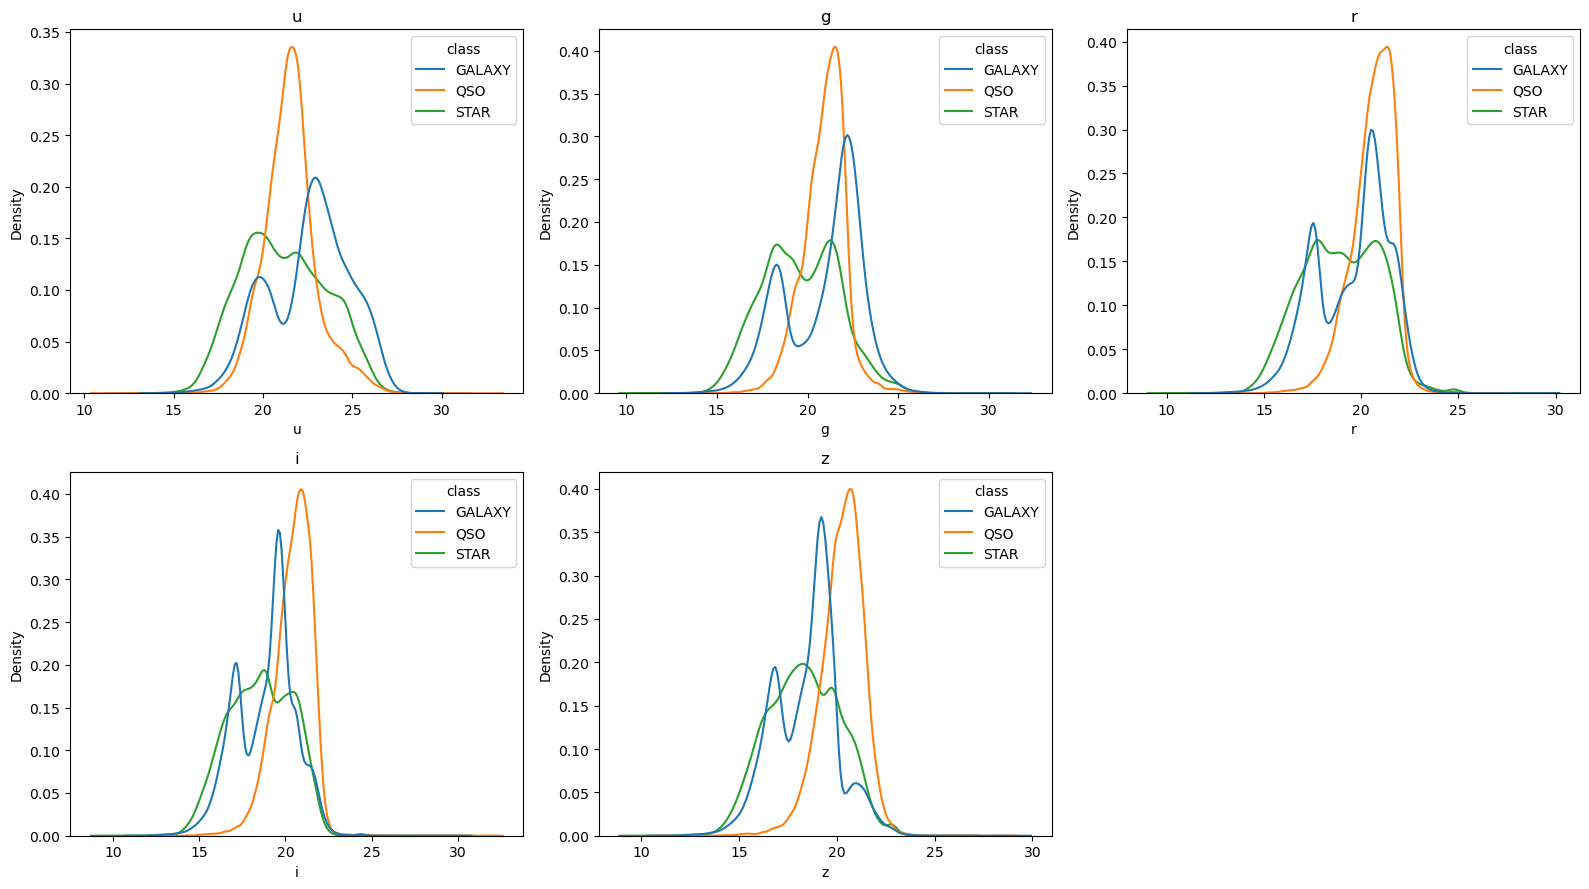

In [268]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
for ax, col in zip(axes.ravel(), ['u','g','r','i','z']):
    sns.kdeplot(data=df, x=col, hue='class', common_norm=False, ax=ax)
    ax.set_title(col)
axes.ravel()[-1].axis('off'); plt.tight_layout()

<Axes: xlabel='g_r', ylabel='u_g'>

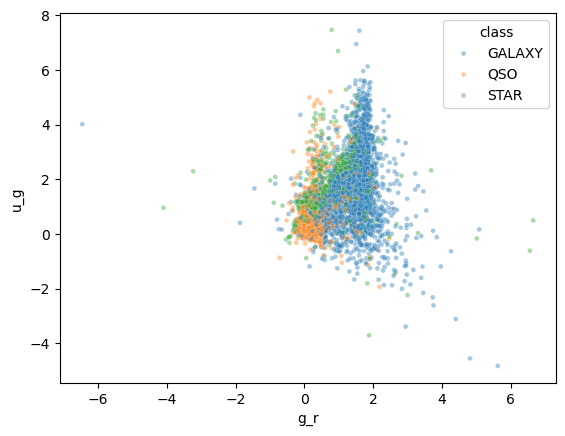

In [269]:
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

sns.scatterplot(data=df.sample(5000), x='g_r', y='u_g', hue='class', alpha=0.4, s=12)

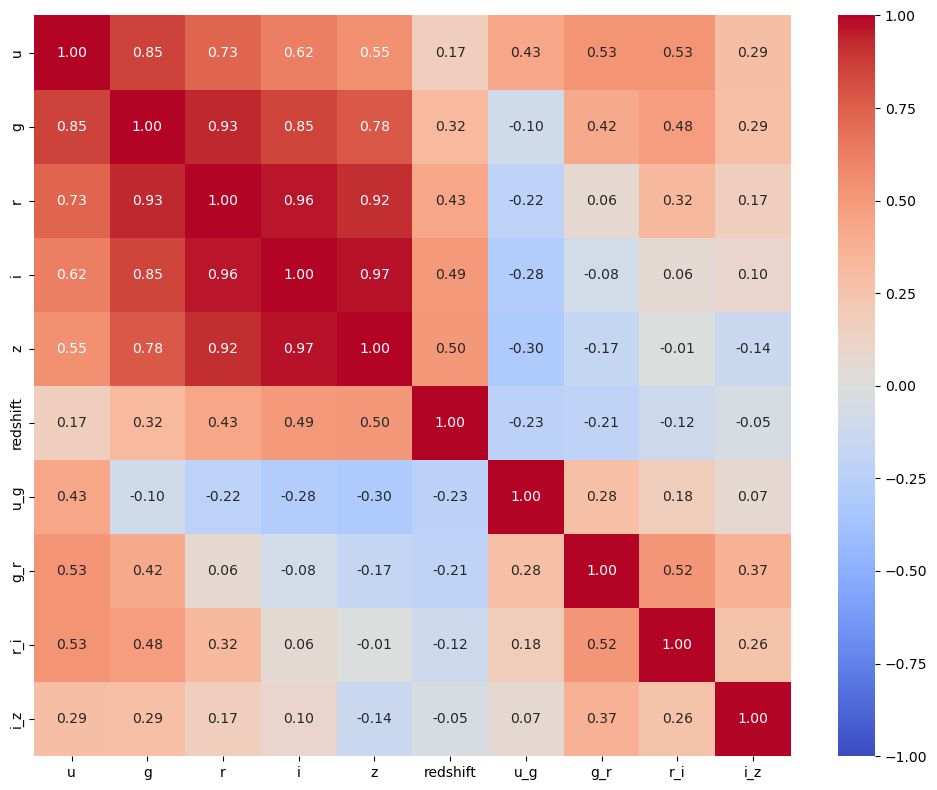

In [270]:
plt.figure(figsize=(10,8))
feat = ['u','g','r','i','z','redshift','u_g','g_r','r_i','i_z']
sns.heatmap(df[feat].corr(), annot=True, cmap='coolwarm', fmt='.2f',vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

#### pairplot, but only on 50000 sample

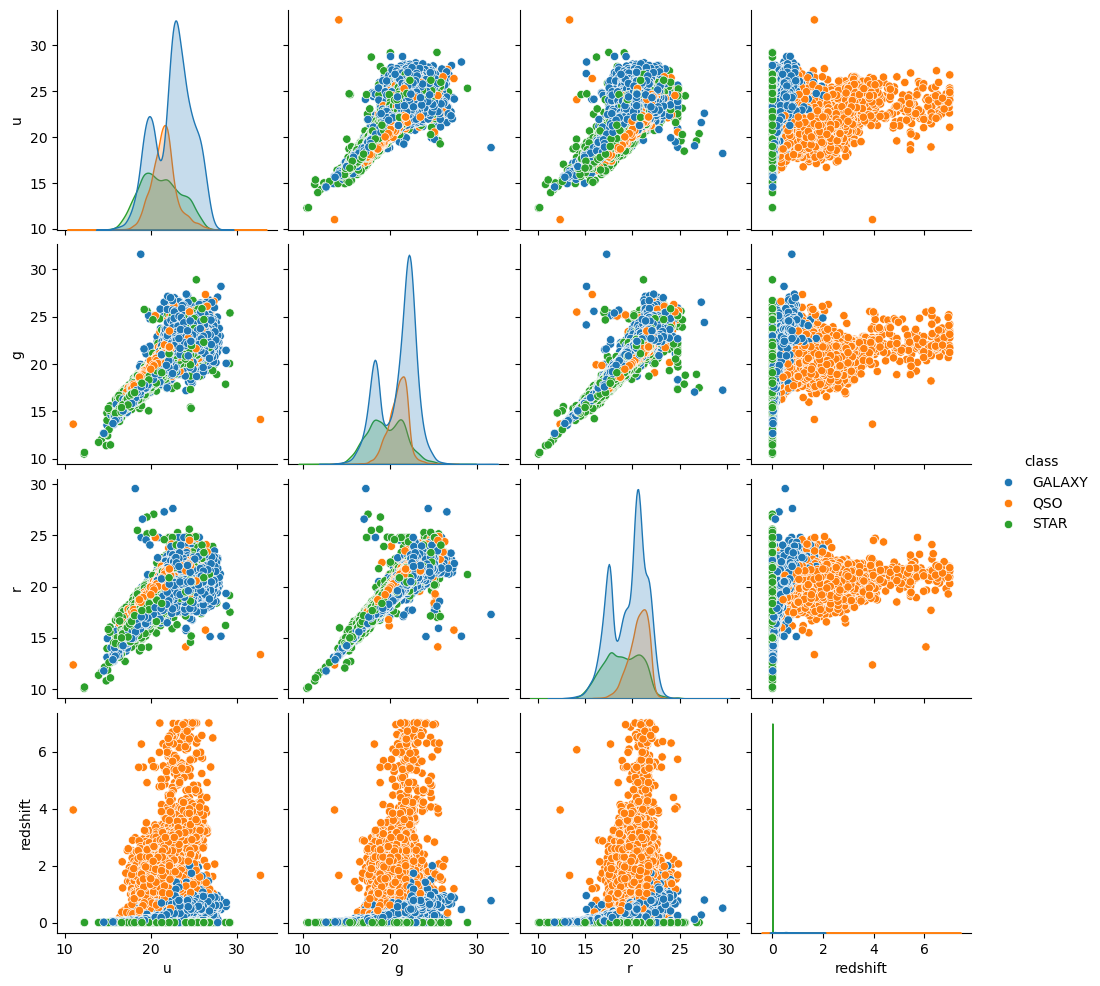

In [271]:
sns.pairplot(df.sample(50000)[['u','g','r','redshift','class']], hue='class')